In [3]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report,confusion_matrix,ConfusionMatrixDisplay



In [4]:
train = pd.read_csv(r'../dataset/train.csv')

In [5]:
TARGET = "health_condition"
FEATURES = [c for c in train.columns if c not in ["id", TARGET]]

In [6]:
numeric_cols = ["sleep_duration", "heart_rate", "bmi", "calorie_expenditure",
                "step_count", "exercise_duration", "water_intake"]
categorical_cols = ["diet_type", "stress_level", "sleep_quality",
                     "physical_activity_level", "smoking_alcohol", "gender"]

In [7]:
for col in numeric_cols:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)



for col in categorical_cols:
    train[col] = train[col].fillna("missing")


In [8]:
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    encoders[col] = le
 
target_encoder = LabelEncoder()
train["target_enc"] = target_encoder.fit_transform(train[TARGET])
print("Class mapping:", dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))

Class mapping: {'at-risk': np.int64(0), 'fit': np.int64(1), 'unhealthy': np.int64(2)}


In [9]:
X = train[FEATURES]
y = train["target_enc"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_val.shape)

(552070, 13) (138018, 13)


In [10]:
rf_model = RandomForestClassifier(
    n_estimators=300,      
    max_depth=12,           
    min_samples_leaf=20,    
    n_jobs=-1,              
    random_state=42
)

rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

In [11]:
val_pred = rf_model.predict(X_val)

In [12]:
print("Accuracy:", accuracy_score(y_val, val_pred))
print("f1_score:", f1_score(y_val, val_pred,average="macro"))  
print(classification_report(y_val, val_pred, target_names=target_encoder.classes_))
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances)

Accuracy: 0.9657218623657784
f1_score: 0.9034300035274122
              precision    recall  f1-score   support

     at-risk       0.96      1.00      0.98    118512
         fit       0.95      0.80      0.87      7961
   unhealthy       0.99      0.76      0.86     11545

    accuracy                           0.97    138018
   macro avg       0.97      0.85      0.90    138018
weighted avg       0.97      0.97      0.96    138018

stress_level               0.440493
sleep_duration             0.374830
physical_activity_level    0.093888
bmi                        0.037166
step_count                 0.014615
exercise_duration          0.012627
sleep_quality              0.012419
smoking_alcohol            0.006914
calorie_expenditure        0.002667
heart_rate                 0.001798
water_intake               0.001773
diet_type                  0.000406
gender                     0.000404
dtype: float64


[[118137    295     80]
 [  1551   6380     30]
 [  2761     14   8770]]


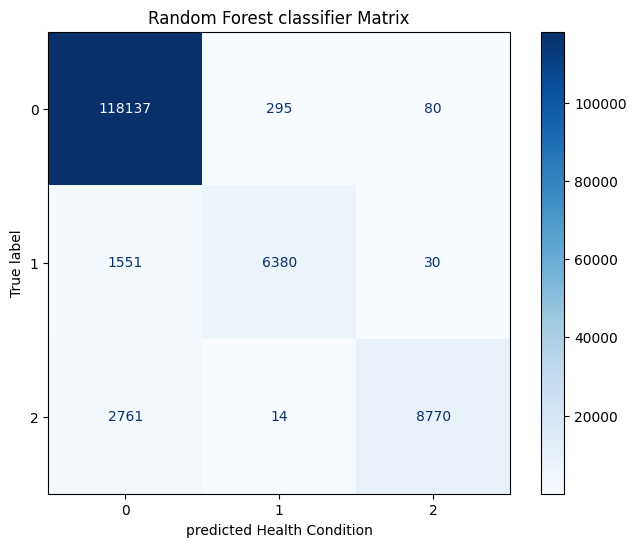

In [13]:


cm = confusion_matrix(y_val, val_pred)
print(cm)


fig, ax = plt.subplots(figsize=(8,6))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    val_pred,
    display_labels=rf_model.classes_,
    cmap="Blues",
    ax=ax
)

plt.title("Random Forest classifier Matrix")
plt.xlabel("predicted Health Condition")
plt.show()

In [14]:
os.makedirs("models_rf", exist_ok=True)

joblib.dump(rf_model, "models_rf/rf_model.pkl")
joblib.dump(encoders, "models_rf/feature_encoders.pkl")
joblib.dump(target_encoder, "models_rf/target_encoder.pkl")
joblib.dump(FEATURES, "models_rf/feature_names.pkl")

preprocessing_info = {
    "numeric_columns": numeric_cols,
    "categorical_columns": categorical_cols,
    "numeric_medians": {col: train[col].median() for col in numeric_cols},
    "categorical_fill": "missing"
}

joblib.dump(preprocessing_info, "models_rf/preprocessing_info.pkl")

print("All artifacts saved successfully!")

All artifacts saved successfully!


In [16]:
test_df = pd.read_csv(r"../Dataset/test.csv")

test_ids = test_df["id"]

# Fill numeric missing values
for col in preprocessing_info["numeric_columns"]:
    median = preprocessing_info["numeric_medians"][col]
    test_df[col] = test_df[col].fillna(median)

# Fill categorical missing values
for col in preprocessing_info["categorical_columns"]:
    test_df[col] = test_df[col].fillna(preprocessing_info["categorical_fill"])

# Encode categorical columns
for col in preprocessing_info["categorical_columns"]:
    encoder = encoders[col]
    known_values = set(encoder.classes_)

    test_df[col] = test_df[col].apply(
        lambda x: x if x in known_values else "missing"
    )

    test_df[col] = encoder.transform(test_df[col])

# Keep correct feature order
test_df = test_df[FEATURES]

# Predict
pred_enc = rf_model.predict(test_df)
predictions = target_encoder.inverse_transform(pred_enc)

# Create submission
submission = pd.DataFrame({
    "id": test_ids,
    "health_condition": predictions
})

# Save
os.makedirs("Submissions", exist_ok=True)
submission.to_csv("Submissions/rf_submission.csv", index=False)

print("RF submission created successfully!")
print(submission.head())
print(submission.shape)

RF submission created successfully!
       id health_condition
0  690088        unhealthy
1  690089          at-risk
2  690090          at-risk
3  690091          at-risk
4  690092        unhealthy
(295753, 2)
